# DATASET

## mass: stellar mass in units of solar mass.
## luminosity: stellar luminosity in units of solar luminosity.

In [10]:
mass = [0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4]

luminosity = [0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0]

# Stellar Luminosity Hands-On

## 1. Environment Setup

In [11]:
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
### Import required libraries

import numpy as np
import matplotlib.pyplot as plt

## Loading the dataset as NumPy arrays.

In [13]:
mass = np.array(mass)
luminosity = np.array(luminosity)

##  Shapes and ranges of the variables.

In [14]:
massShape = mass.shape
massRange = np.arange(massShape[0])
luminosityShape = luminosity.shape
luminosityRange = np.arange(luminosityShape[0])
print("Mass shape:", massShape)
print("Mass range:", massRange)
print("Luminosity shape:", luminosityShape)
print("Luminosity range:", luminosityRange)

Mass shape: (10,)
Mass range: [0 1 2 3 4 5 6 7 8 9]
Luminosity shape: (10,)
Luminosity range: [0 1 2 3 4 5 6 7 8 9]


## Ploting 

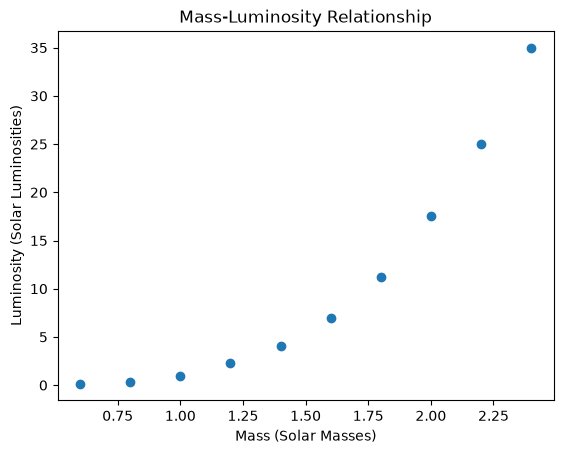

In [15]:
plt.figure()
plt.plot(mass, luminosity, 'o')
plt.xlabel('Mass (Solar Masses)')
plt.ylabel('Luminosity (Solar Luminosities)')
plt.title('Mass-Luminosity Relationship')
plt.yticks(np.arange(0, 40, 5))
plt.show()

The graph shows a nonlinear relationship where luminosity increases at an increasing rate as stellar mass increases.

## Linear Model Suitability

A straight line does not appear to be adequate because it cannot accurately follow the nonlinear trend of the data. As a result, the linear regression model would produce systematic errors, especially for observations with higher stellar masses.   

## Implementing the learning algorithm

In [16]:
def prediction(x, w, b):
    # Placeholder for the learning algorithm implementation
    y_hat = x @ w + b
    return y_hat

## Mean squared error

In [17]:
def meanSquaredError(y_hat, y_true):
    m=y_true.shape[0]
    return 1/(2 * m) * np.sum((y_hat - y_true) ** 2)

## Gradient 

In [18]:
def gradient(x, y, w, b):
    m = y.shape[0]
    predictions = prediction(x, w, b)
    error = predictions - y
    dw = (x.T @ error) / m
    db = 1/m * np.sum(error)

    return dw, db

## Gradient descent  

In [19]:
def gradientDescent(x, y, w_init, b_init, alpha, num_iterations):
    w = w_init
    b = b_init
    cost_history = []

    for i in range(num_iterations):
        dw, db = gradient(x, y, w, b)

        w = w - alpha * dw
        b = b - alpha * db

        cost_history.append(meanSquaredError(prediction(x, w, b), y))

    return w, b, cost_history

## Training model

In [62]:
X_linear = mass.reshape(-1, 1)
w_init = np.array([0.0])
b_init = 0.0
learning_rate = 0.01
num_iterations = 1000
w_linear, b_linear, linear_cost_history = gradientDescent(X_linear, luminosity, w_init, b_init, learning_rate, num_iterations)


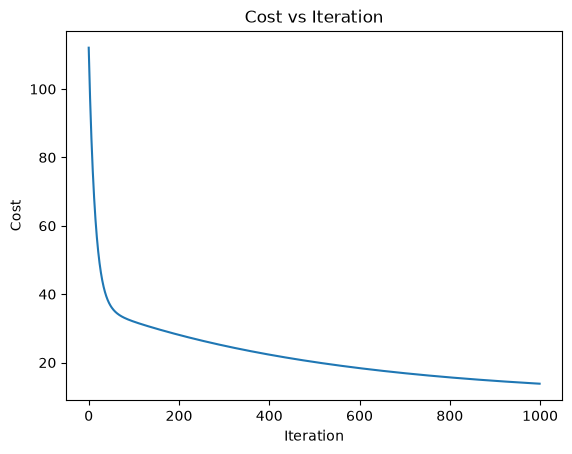

In [63]:
plt.figure()
plt.plot(linear_cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost vs Iteration")
plt.show()

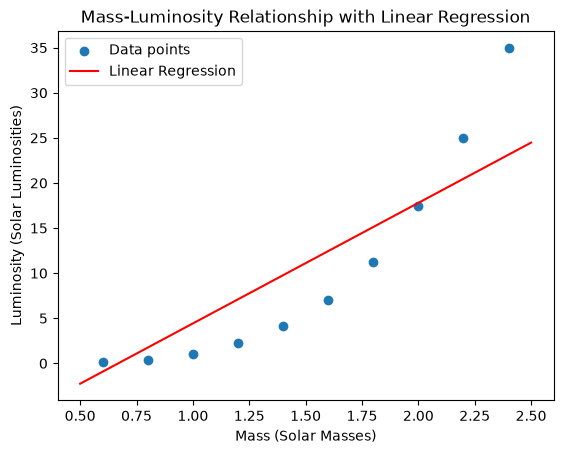

In [65]:
plot_x = np.linspace(0.5, 2.5, 100).reshape(-1, 1)
plot_y = prediction(plot_x, w_linear, b_linear)   
plt.figure()
plt.scatter(mass, luminosity, label='Data points')
plt.plot(plot_x, plot_y, label='Linear Regression', color='red')
plt.xlabel('Mass (Solar Masses)')
plt.ylabel('Luminosity (Solar Luminosities)')
plt.title('Mass-Luminosity Relationship with Linear Regression')
plt.legend()
plt.show()


In [78]:
print("Learned weight (w):", w_linear)
print("Learned bias (b):", b_linear)
print("Final cost:", linear_cost_history[-1])
print("Predicted luminosity for a star with mass 1.5 solar masses:", prediction(np.array([[1.5]]), w_linear, b_linear)[0])

Learned weight (w): [13.3647611]
Learned bias (b): -8.939532714878704
Final cost: 13.821822375363263
Predicted luminosity for a star with mass 1.5 solar masses: 11.107608939062045


## SYSTEMATIC ERRORS 

## 5 

In [59]:
X_polynomial = np.column_stack((mass, mass**2))
w_init_poly = np.array([0.0, 0.0])
b_init_poly = 0.0
learning_rate_poly = 0.01
num_iterations_poly = 1000
w_poly, b_poly , poly_cost_history = gradientDescent(X_polynomial, luminosity, w_init_poly, b_init_poly, learning_rate_poly, num_iterations_poly)

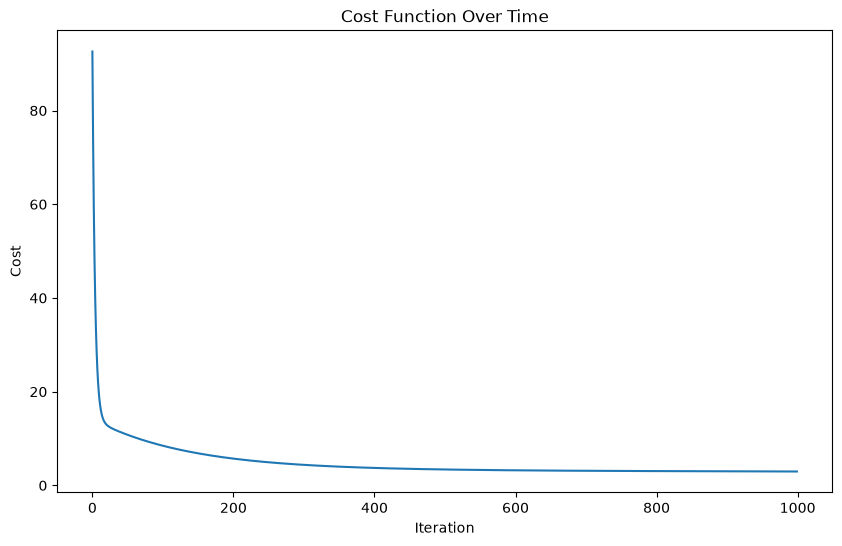

In [57]:
plt.figure(figsize=(10, 6))
plt.plot(poly_cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost Function Over Time")
plt.show()

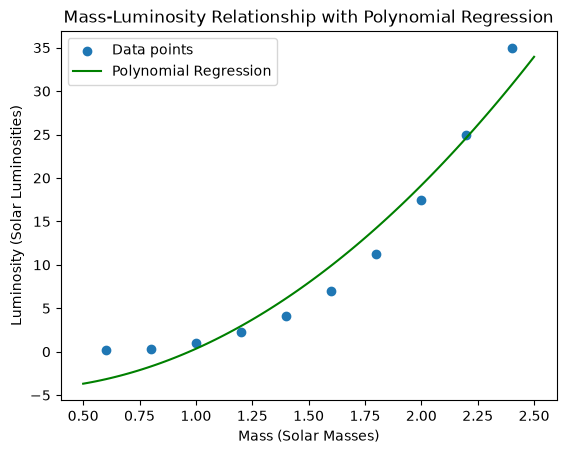

In [61]:
plot_x_poly = np.linspace(0.5, 2.5, 100)
plot_y_poly = prediction(np.column_stack((plot_x_poly, plot_x_poly**2)), w_poly, b_poly)
plt.figure()
plt.scatter(mass, luminosity, label='Data points')
plt.plot(plot_x_poly, plot_y_poly, label='Polynomial Regression', color='green')
plt.xlabel('Mass (Solar Masses)')
plt.ylabel('Luminosity (Solar Luminosities)')
plt.title('Mass-Luminosity Relationship with Polynomial Regression')
plt.legend()
plt.show()

In [77]:
print("Final weight (w):", w_poly)
print("Final bias (b):", b_poly)
print("Final cost:", poly_cost_history[-1])
print("Predicted luminosity for a star with mass 1.5 solar masses (Polynomial Regression):", prediction(np.array([[1.5, 1.5**2]]), w_poly, b_poly)[0])

Final weight (w): [-2.73178946  7.18267955]
Final bias (b): -4.111102073580276
Final cost: 2.9622865161817993
Predicted luminosity for a star with mass 1.5 solar masses (Polynomial Regression): 7.952242731253867


## What change

## Comparing the cost 

In [53]:
print("linear cost history:", linear_cost_history[-1])
print("polynomial cost history:", poly_cost_history[-1])

linear cost history: 13.821822375363263
polynomial cost history: 2.9622865161817993


In [69]:
y_hat_linear = prediction(X_linear, w_linear, b_linear)
y_hat_poly = prediction(X_polynomial, w_poly, b_poly)
residual_linear = luminosity - y_hat_linear
residual_poly = luminosity - y_hat_poly

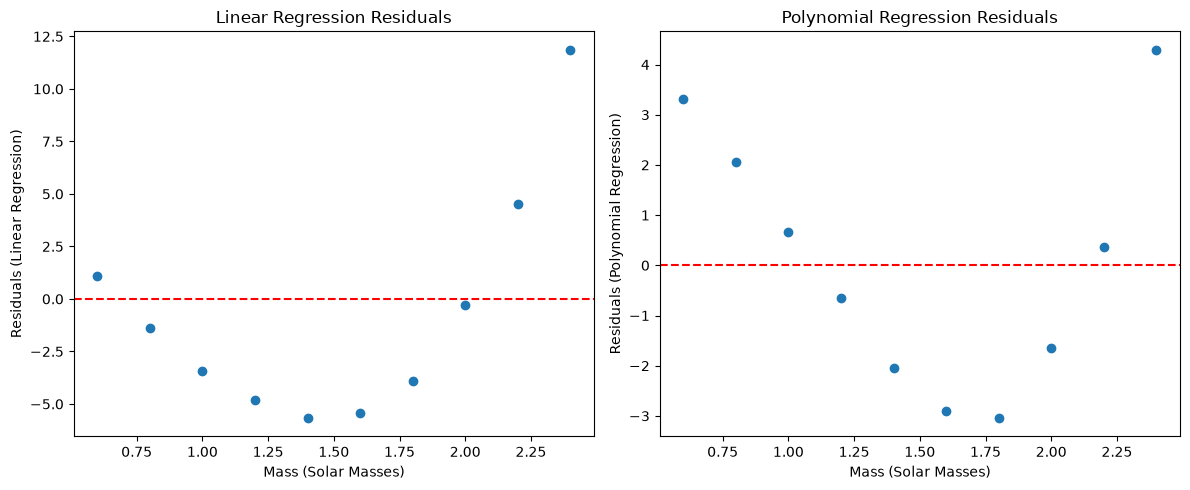

In [71]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)    
plt.scatter(mass, residual_linear)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Mass (Solar Masses)')
plt.ylabel('Residuals (Linear Regression)')
plt.title('Linear Regression Residuals')
plt.subplot(1, 2, 2)
plt.scatter(mass, residual_poly)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Mass (Solar Masses)')
plt.ylabel('Residuals (Polynomial Regression)')
plt.title('Polynomial Regression Residuals')
plt.tight_layout()
plt.show()

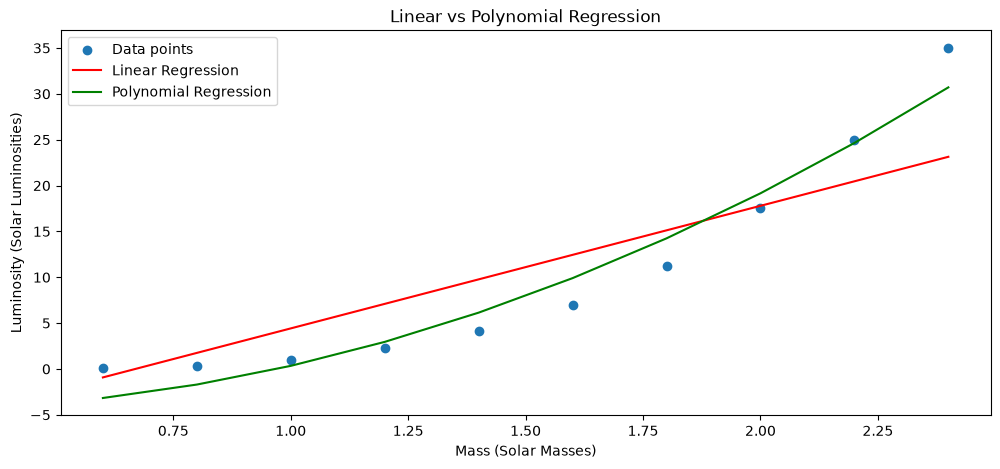

In [75]:
plt.figure(figsize=(12, 5))
plt.scatter(mass, luminosity, label='Data points')
plt.xlabel('Mass (Solar Masses)')
plt.ylabel('Luminosity (Solar Luminosities)')
plt.title("Linear vs Polynomial Regression")
plt.plot(mass, y_hat_linear, label='Linear Regression', color='red')
plt.plot(mass, y_hat_poly, label='Polynomial Regression', color='green')
plt.legend()
plt.show()

In [ ]:
x1_linear = np.array([[5]])
print("Mass = 5")
print("linear:", prediction(x1_linear, w_linear, b_linear)[0])

Mass = 5
linear: 57.884272798257136


In [ ]:
x2_linear = np.array([[1.3]])
print("Mass = 1.3")
print("linear:", prediction(x2_linear, w_linear, b_linear)[0])


Mass = 1.3
linear: 8.434656718536614


In [ ]:

x1_poly=np.append(5, 5**2).reshape(1, -1)
print("Mass = 5")
print("polynomial:", prediction(x1_poly, w_poly, b_poly)[0])

Mass = 5
polynomial: 161.7969394639031


In [ ]:

x2_poly = np.append(1.3, 1.3**2).reshape(1, -1)
print("Mass = 1.3")
print("polynomial:", prediction(x2_poly, w_poly, b_poly)[0])

Mass = 1.3
polynomial: 4.476300073339446
